# High-Engagement Listing Predictor for Real Estate Platforms
### ITAI 1371 – Introduction to Machine Learning | Midterm Project
**Student:** Trilok Kalani  
**Dataset:** United States House Listings – Zillow Extract 2023 (Kaggle)  
**Goal:** Predict whether a real-estate listing will receive HIGH engagement (binary classification)

## Section 1 – Import Libraries

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

from sklearn.model_selection import train_test_split, cross_val_score, GridSearchCV
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.impute import SimpleImputer
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score,
    confusion_matrix, classification_report, roc_auc_score, roc_curve
)

# Plot styling
sns.set_theme(style='whitegrid', palette='muted')
plt.rcParams['figure.dpi'] = 120
print('Libraries loaded successfully.')

Libraries loaded successfully.


## Section 2 – Load Dataset

In [3]:
df = pd.read_csv('cleaned_df.csv')
print(f'Dataset shape: {df.shape}')
print(f'Columns: {list(df.columns)}')
df.head()

Dataset shape: (22681, 14)
Columns: ['State', 'City', 'Street', 'Zipcode', 'Bedroom', 'Bathroom', 'Area', 'PPSq', 'LotArea', 'MarketEstimate', 'RentEstimate', 'Latitude', 'Longitude', 'ListedPrice']


,State,City,Street,Zipcode,Bedroom,Bathroom,Area,PPSq,LotArea,MarketEstimate,RentEstimate,Latitude,Longitude,ListedPrice
0,AL,Saraland,Scott Dr,36571.0,4.0,2.0,1614.0,148.636927,0.3805,240600.0,1599.0,30.819534,-88.095960,239900.0
1,AL,Robertsdale,Cowpen Creek Rd,36567.0,3.0,2.0,1800.0,144.388889,3.2000,NaN,NaN,30.590004,-87.580376,259900.0
2,AL,Gulf Shores,Spinnaker Dr #201,36542.0,2.0,2.0,1250.0,274.000000,NaN,NaN,NaN,30.284956,-87.747920,342500.0
3,AL,Chelsea,Mallet Way,35043.0,3.0,3.0,2224.0,150.629496,0.2600,336200.0,1932.0,33.357986,-86.608700,335000.0
4,AL,Huntsville,Turtlebrook Ct,35811.0,3.0,2.0,1225.0,204.081633,NaN,222700.0,1679.0,34.775517,-86.440700,250000.0


In [4]:
print('=== Basic Info ===')
df.info()
print('\n=== Descriptive Statistics ===')
df.describe().round(2)

=== Basic Info ===
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 22681 entries, 0 to 22680
Data columns (total 14 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   State           22681 non-null  object 
 1   City            22681 non-null  object 
 2   Street          22681 non-null  object 
 3   Zipcode         22681 non-null  float64
 4   Bedroom         22667 non-null  float64
 5   Bathroom        22647 non-null  float64
 6   Area            22681 non-null  float64
 7   PPSq            22681 non-null  float64
 8   LotArea         21779 non-null  float64
 9   MarketEstimate  15445 non-null  float64
 10  RentEstimate    16705 non-null  float64
 11  Latitude        22681 non-null  float64
 12  Longitude       22681 non-null  float64
 13  ListedPrice     22681 non-null  float64
dtypes: float64(11), object(3)
memory usage: 2.4+ MB

=== Descriptive Statistics ===


,Zipcode,Bedroom,Bathroom,Area,PPSq,LotArea,MarketEstimate,RentEstimate,Latitude,Longitude,ListedPrice
count,22681.00,22667.00,22647.00,22681.00,22681.00,21779.00,15445.00,16705.00,22681.00,22681.00,22681.00
mean,50023.46,3.39,2.42,2128.14,222.64,2.35,487038.31,2624.70,39.75,-92.30,532439.91
std,29570.31,1.05,1.16,1577.51,202.81,16.13,1155985.72,4029.61,5.69,16.87,1574921.81
min,1002.00,0.00,0.00,120.00,1.93,0.00,15700.00,100.00,25.45,-161.77,4888.00
25%,25419.00,3.00,2.00,1400.00,132.73,0.17,230600.00,1641.00,35.94,-103.32,225000.00
50%,50703.00,3.00,2.00,1849.00,184.12,0.30,341700.00,2149.00,39.94,-89.19,344900.00
75%,74134.00,4.00,3.00,2466.00,257.12,0.93,499500.00,2800.00,42.94,-79.11,499900.00
max,99950.00,21.00,25.00,99990.00,6117.07,800.00,71959200.00,212834.00,65.04,-67.02,76000000.00


In [8]:
print('=== Missing Values ===')
missing = df.isnull().sum()
missing_pct = (missing / len(df) * 100).round(2)
missing_df = pd.DataFrame({'Count': missing, 'Percentage (%)': missing_pct})
print(missing_df[missing_df['Count'] > 0])

=== Missing Values ===
                Count  Percentage (%)
Bedroom            14            0.06
Bathroom           34            0.15
LotArea           902            3.98
MarketEstimate   7236           31.90
RentEstimate     5976           26.35


## Section 3 – Target Variable Engineering

**Engagement Proxy:** Since direct engagement metrics (views, saves) are not publicly available,
we engineer a target using the ratio of `MarketEstimate` to `ListedPrice`.

- Listings priced **below market value** (ratio > 1) attract far more buyer interest and platform engagement.
- This is consistent with real-world Zillow behavior: underpriced listings get more saves, views, and inquiries.
- We label the **top 25%** of engagement-score listings as **High Engagement (1)**, rest as **Low (0)**.

This approach mirrors what was described in the project proposal.

In [7]:
# Keep only rows where both MarketEstimate and ListedPrice are available
df_eng = df.dropna(subset=['MarketEstimate', 'ListedPrice']).copy()
df_eng = df_eng[df_eng['ListedPrice'] > 0]  # Remove zero prices

# Engagement score: higher ratio = more underpriced relative to market = more attractive
df_eng['engagement_score'] = df_eng['MarketEstimate'] / df_eng['ListedPrice']

# Binary label: top 25% = High Engagement (1)
threshold = df_eng['engagement_score'].quantile(0.75)
df_eng['high_engagement'] = (df_eng['engagement_score'] >= threshold).astype(int)

print(f'Rows after filtering: {len(df_eng)}')
print(f'Engagement score threshold (75th pct): {threshold:.4f}')
print(f'\nClass distribution:')
print(df_eng['high_engagement'].value_counts())
print(f'\nClass balance: {df_eng["high_engagement"].mean()*100:.1f}% High Engagement')

Rows after filtering: 15445
Engagement score threshold (75th pct): 1.0041

Class distribution:
high_engagement
0    11583
1     3862
Name: count, dtype: int64

Class balance: 25.0% High Engagement


## Section 4 – Exploratory Data Analysis (EDA)

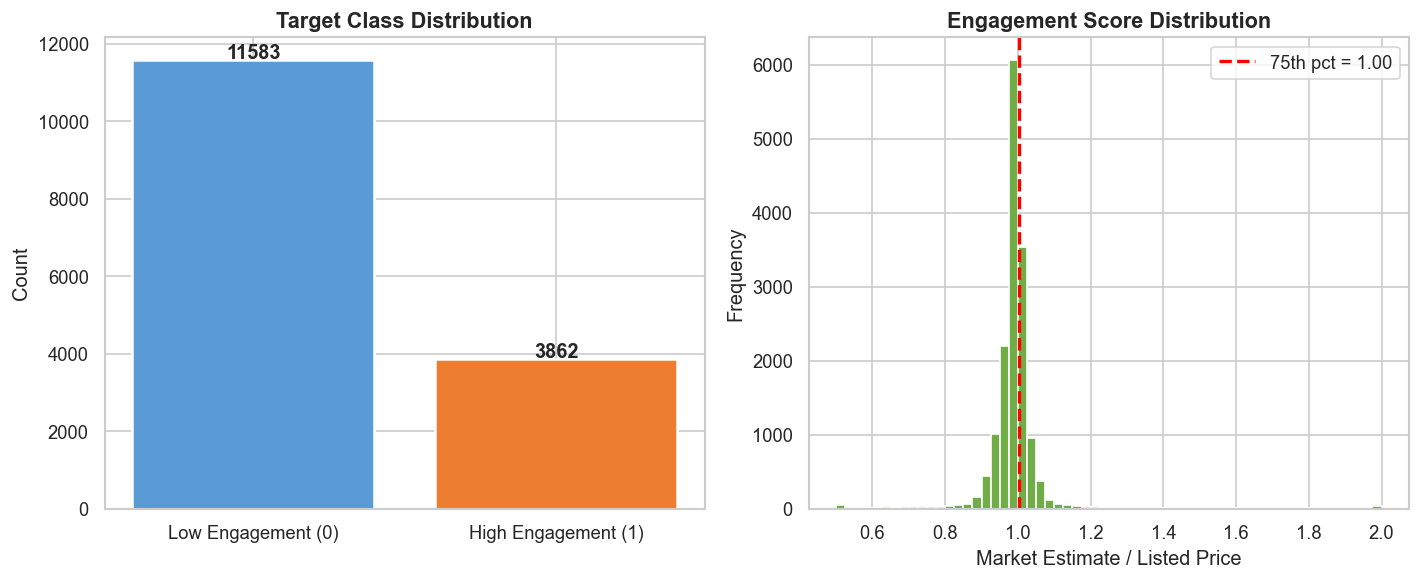

Plot saved.


In [9]:
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

# Class distribution
counts = df_eng['high_engagement'].value_counts()
axes[0].bar(['Low Engagement (0)', 'High Engagement (1)'], counts.values,
            color=['#5B9BD5', '#ED7D31'], edgecolor='white', linewidth=1.5)
axes[0].set_title('Target Class Distribution', fontsize=13, fontweight='bold')
axes[0].set_ylabel('Count')
for i, v in enumerate(counts.values):
    axes[0].text(i, v + 50, str(v), ha='center', fontweight='bold')

# Engagement score distribution
axes[1].hist(df_eng['engagement_score'].clip(0.5, 2.0), bins=60, color='#70AD47', edgecolor='white')
axes[1].axvline(threshold, color='red', linestyle='--', linewidth=2, label=f'75th pct = {threshold:.2f}')
axes[1].set_title('Engagement Score Distribution', fontsize=13, fontweight='bold')
axes[1].set_xlabel('Market Estimate / Listed Price')
axes[1].set_ylabel('Frequency')
axes[1].legend()

plt.tight_layout()
plt.savefig('plot_01_class_distribution.png', bbox_inches='tight')
plt.show()
print('Plot saved.')

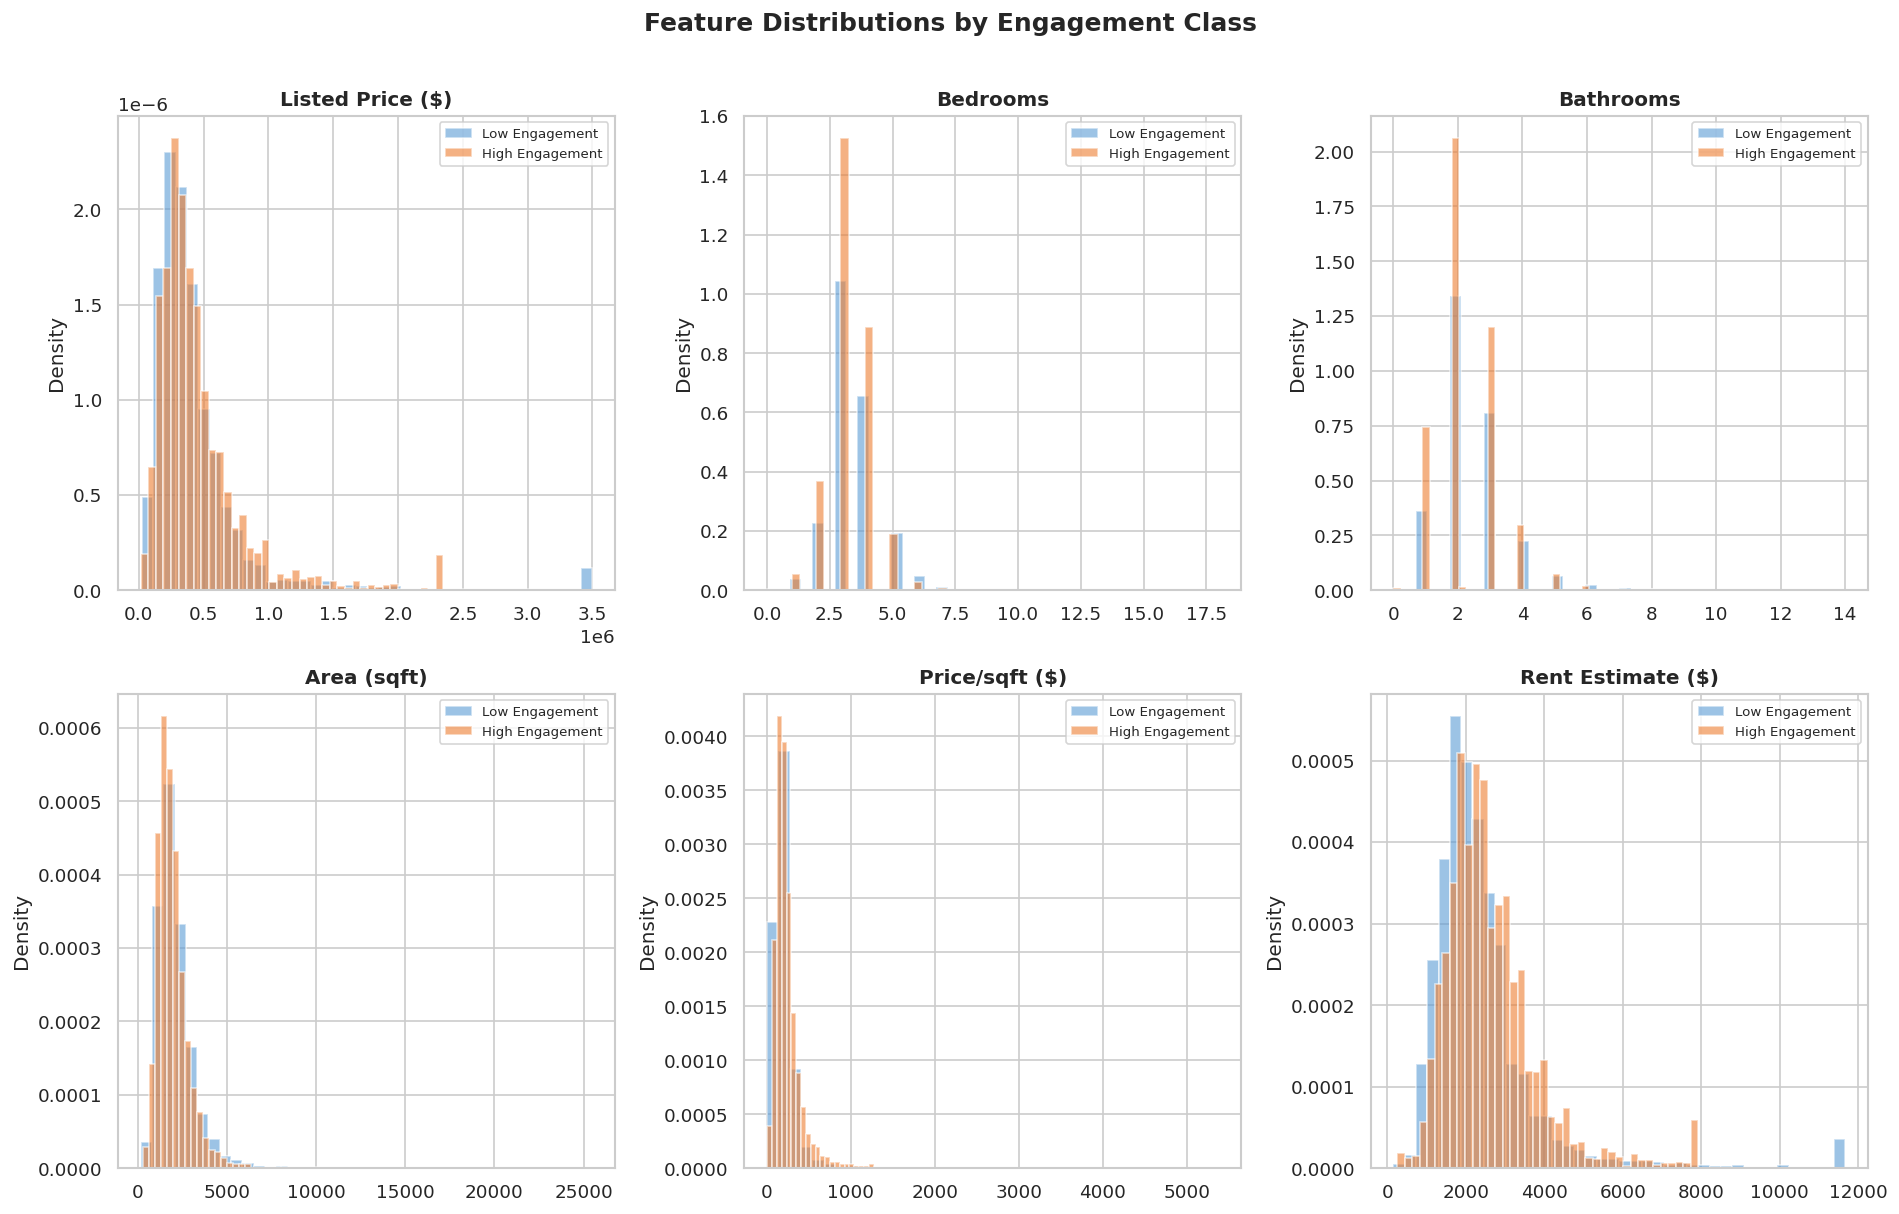

Plot saved.


In [7]:
fig, axes = plt.subplots(2, 3, figsize=(16, 10))
num_features = ['ListedPrice', 'Bedroom', 'Bathroom', 'Area', 'PPSq', 'RentEstimate']
titles = ['Listed Price ($)', 'Bedrooms', 'Bathrooms', 'Area (sqft)', 'Price/sqft ($)', 'Rent Estimate ($)']

for ax, feat, title in zip(axes.flatten(), num_features, titles):
    for label, color, name in zip([0, 1], ['#5B9BD5', '#ED7D31'], ['Low', 'High']):
        data = df_eng[df_eng['high_engagement'] == label][feat].dropna()
        if feat in ['ListedPrice', 'RentEstimate']:
            data = data.clip(upper=data.quantile(0.99))
        ax.hist(data, bins=40, alpha=0.6, color=color, label=f'{name} Engagement', density=True)
    ax.set_title(title, fontweight='bold')
    ax.set_ylabel('Density')
    ax.legend(fontsize=8)

plt.suptitle('Feature Distributions by Engagement Class', fontsize=15, fontweight='bold', y=1.01)
plt.tight_layout()
plt.savefig('plot_02_feature_distributions.png', bbox_inches='tight')
plt.show()
print('Plot saved.')

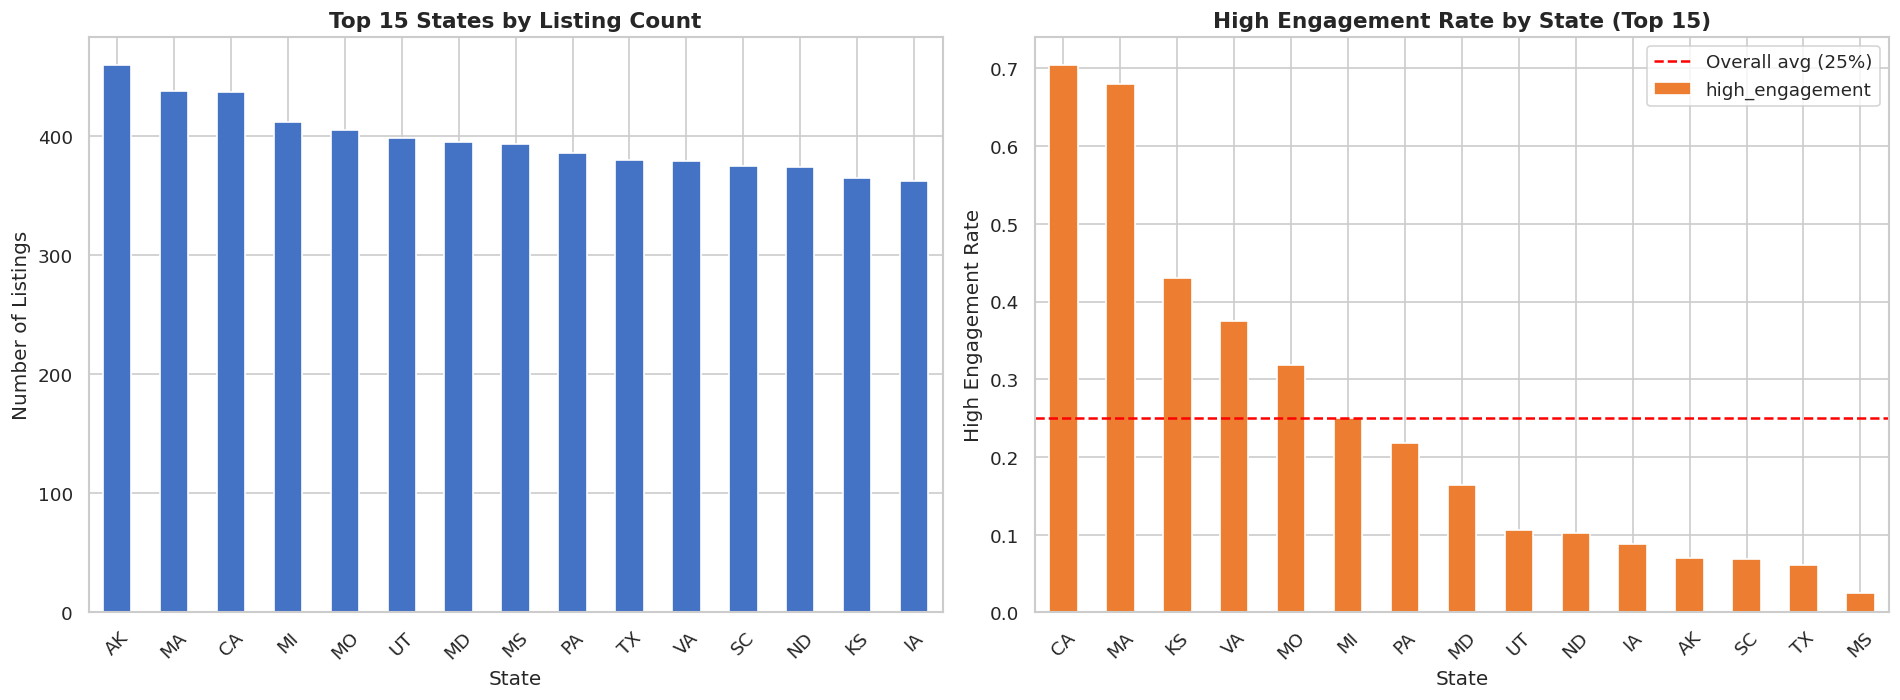

Plot saved.


In [8]:
# Top 15 states by listing count
top_states = df_eng['State'].value_counts().head(15)
state_engagement = df_eng.groupby('State')['high_engagement'].mean().reindex(top_states.index)

fig, axes = plt.subplots(1, 2, figsize=(16, 6))

top_states.plot(kind='bar', ax=axes[0], color='#4472C4')
axes[0].set_title('Top 15 States by Listing Count', fontsize=13, fontweight='bold')
axes[0].set_xlabel('State')
axes[0].set_ylabel('Number of Listings')
axes[0].tick_params(axis='x', rotation=45)

state_engagement.sort_values(ascending=False).plot(kind='bar', ax=axes[1], color='#ED7D31')
axes[1].set_title('High Engagement Rate by State (Top 15)', fontsize=13, fontweight='bold')
axes[1].set_xlabel('State')
axes[1].set_ylabel('High Engagement Rate')
axes[1].axhline(0.25, color='red', linestyle='--', label='Overall avg (25%)')
axes[1].legend()
axes[1].tick_params(axis='x', rotation=45)

plt.tight_layout()
plt.savefig('plot_03_state_analysis.png', bbox_inches='tight')
plt.show()
print('Plot saved.')

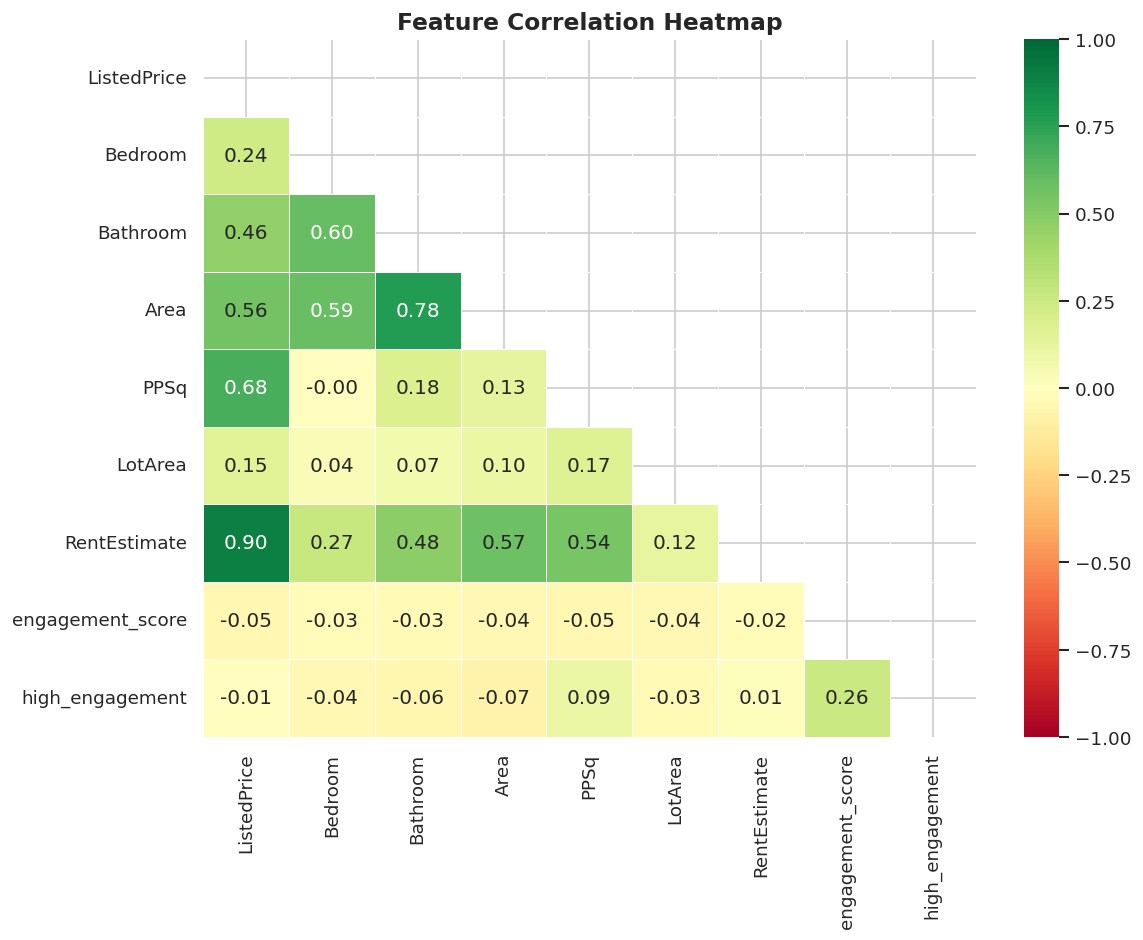

Plot saved.


In [9]:
# Correlation heatmap
corr_features = ['ListedPrice', 'Bedroom', 'Bathroom', 'Area', 'PPSq',
                 'LotArea', 'RentEstimate', 'engagement_score', 'high_engagement']
corr_df = df_eng[corr_features].dropna()

plt.figure(figsize=(10, 8))
mask = np.triu(np.ones_like(corr_df.corr(), dtype=bool))
sns.heatmap(corr_df.corr(), annot=True, fmt='.2f', cmap='RdYlGn',
            mask=mask, vmin=-1, vmax=1, linewidths=0.5)
plt.title('Feature Correlation Heatmap', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('plot_04_correlation_heatmap.png', bbox_inches='tight')
plt.show()
print('Plot saved.')

## Section 5 – Data Preprocessing

In [10]:
# Select features for modeling
# Drop columns not useful for prediction (identifiers, leaky features)
feature_cols = ['Bedroom', 'Bathroom', 'Area', 'PPSq', 'LotArea',
                'RentEstimate', 'ListedPrice', 'State']
target_col = 'high_engagement'

df_model = df_eng[feature_cols + [target_col]].copy()
print(f'Modeling dataset shape: {df_model.shape}')
print(f'Missing values:\n{df_model.isnull().sum()}')

Modeling dataset shape: (15445, 9)
Missing values:
Bedroom              5
Bathroom            20
Area                 0
PPSq                 0
LotArea            529
RentEstimate        48
ListedPrice          0
State                0
high_engagement      0
dtype: int64


In [11]:
# Encode State (categorical) with Label Encoding
le = LabelEncoder()
df_model['State_encoded'] = le.fit_transform(df_model['State'].astype(str))
df_model.drop('State', axis=1, inplace=True)

# Separate features and target
X = df_model.drop(target_col, axis=1)
y = df_model[target_col]

print(f'Feature matrix shape: {X.shape}')
print(f'Target shape: {y.shape}')
print(f'Feature columns: {list(X.columns)}')

Feature matrix shape: (15445, 8)
Target shape: (15445,)
Feature columns: ['Bedroom', 'Bathroom', 'Area', 'PPSq', 'LotArea', 'RentEstimate', 'ListedPrice', 'State_encoded']


In [12]:
# Impute missing values with median
imputer = SimpleImputer(strategy='median')
X_imputed = pd.DataFrame(imputer.fit_transform(X), columns=X.columns)

# Train/test split (80/20)
X_train, X_test, y_train, y_test = train_test_split(
    X_imputed, y, test_size=0.2, random_state=42, stratify=y
)

# Scale features
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

print(f'Training set: {X_train.shape} | Test set: {X_test.shape}')
print(f'Train class balance: {y_train.mean()*100:.1f}% High Engagement')
print(f'Test class balance:  {y_test.mean()*100:.1f}% High Engagement')

Training set: (12356, 8) | Test set: (3089, 8)
Train class balance: 25.0% High Engagement
Test class balance:  25.0% High Engagement


## Section 6 – Model Training & Evaluation

In [13]:
# Define models to compare
models = {
    'Logistic Regression': LogisticRegression(max_iter=1000, random_state=42),
    'Decision Tree':       DecisionTreeClassifier(max_depth=6, random_state=42),
    'Random Forest':       RandomForestClassifier(n_estimators=100, random_state=42, n_jobs=-1),
    'Gradient Boosting':   GradientBoostingClassifier(n_estimators=100, random_state=42)
}

results = {}

for name, model in models.items():
    # Use scaled data for Logistic Regression, unscaled for tree-based
    if name == 'Logistic Regression':
        model.fit(X_train_scaled, y_train)
        y_pred = model.predict(X_test_scaled)
        y_prob = model.predict_proba(X_test_scaled)[:, 1]
    else:
        model.fit(X_train, y_train)
        y_pred = model.predict(X_test)
        y_prob = model.predict_proba(X_test)[:, 1]
    
    results[name] = {
        'model': model,
        'y_pred': y_pred,
        'y_prob': y_prob,
        'Accuracy':  round(accuracy_score(y_test, y_pred), 4),
        'Precision': round(precision_score(y_test, y_pred), 4),
        'Recall':    round(recall_score(y_test, y_pred), 4),
        'F1 Score':  round(f1_score(y_test, y_pred), 4),
        'ROC-AUC':   round(roc_auc_score(y_test, y_prob), 4)
    }
    print(f'{name:25s} | Acc: {results[name]["Accuracy"]:.4f} | F1: {results[name]["F1 Score"]:.4f} | AUC: {results[name]["ROC-AUC"]:.4f}')

Logistic Regression       | Acc: 0.7514 | F1: 0.0680 | AUC: 0.6562
Decision Tree             | Acc: 0.7766 | F1: 0.3527 | AUC: 0.7268
Random Forest             | Acc: 0.7789 | F1: 0.3774 | AUC: 0.7711
Gradient Boosting         | Acc: 0.7918 | F1: 0.4030 | AUC: 0.8055


Random Forest             | Acc: 0.7789 | F1: 0.3774 | AUC: 0.7711


Gradient Boosting         | Acc: 0.7918 | F1: 0.4030 | AUC: 0.8055


In [14]:
# Summary comparison table
metrics_df = pd.DataFrame({
    name: {k: v for k, v in info.items() if k not in ['model', 'y_pred', 'y_prob']}
    for name, info in results.items()
}).T
print('=== Model Comparison Table ===')
print(metrics_df.to_string())
metrics_df

=== Model Comparison Table ===
                     Accuracy  Precision  Recall  F1 Score  ROC-AUC
Logistic Regression    0.7514     0.5385  0.0363    0.0680   0.6562
Decision Tree          0.7766     0.6395  0.2435    0.3527   0.7268
Random Forest          0.7789     0.6369  0.2681    0.3774   0.7711
Gradient Boosting      0.7918     0.7115  0.2811    0.4030   0.8055


,Accuracy,Precision,Recall,F1 Score,ROC-AUC
Logistic Regression,0.7514,0.5385,0.0363,0.0680,0.6562
Decision Tree,0.7766,0.6395,0.2435,0.3527,0.7268
Random Forest,0.7789,0.6369,0.2681,0.3774,0.7711
Gradient Boosting,0.7918,0.7115,0.2811,0.4030,0.8055


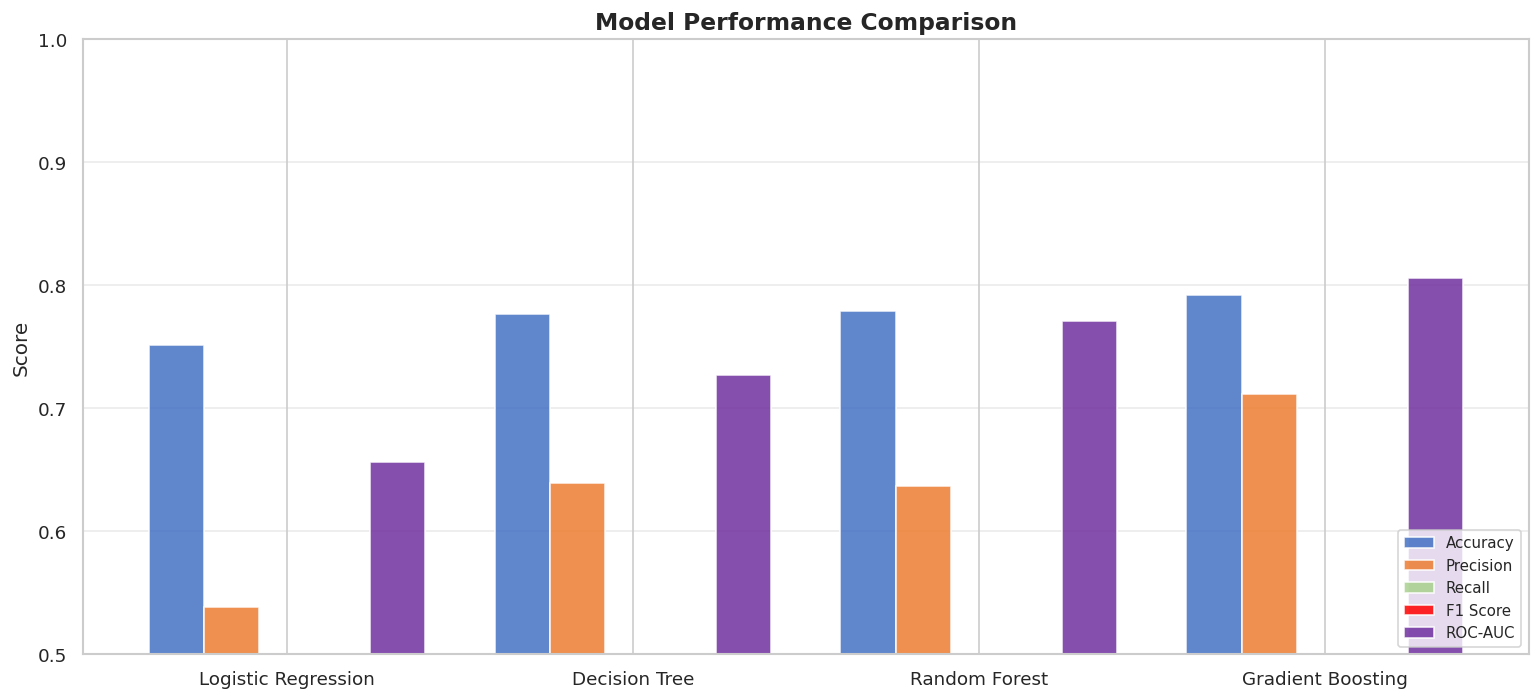

Plot saved.


In [15]:
# Plot: Model comparison bar chart
fig, ax = plt.subplots(figsize=(13, 6))
x = np.arange(len(models))
width = 0.16
metric_names = ['Accuracy', 'Precision', 'Recall', 'F1 Score', 'ROC-AUC']
colors = ['#4472C4', '#ED7D31', '#A9D18E', '#FF0000', '#7030A0']

for i, (metric, color) in enumerate(zip(metric_names, colors)):
    values = [results[m][metric] for m in models]
    bars = ax.bar(x + i * width, values, width, label=metric, color=color, alpha=0.85)

ax.set_xticks(x + width * 2)
ax.set_xticklabels(list(models.keys()), fontsize=11)
ax.set_ylim(0.5, 1.0)
ax.set_ylabel('Score', fontsize=12)
ax.set_title('Model Performance Comparison', fontsize=14, fontweight='bold')
ax.legend(loc='lower right', fontsize=9)
ax.grid(axis='y', alpha=0.4)

plt.tight_layout()
plt.savefig('plot_05_model_comparison.png', bbox_inches='tight')
plt.show()
print('Plot saved.')

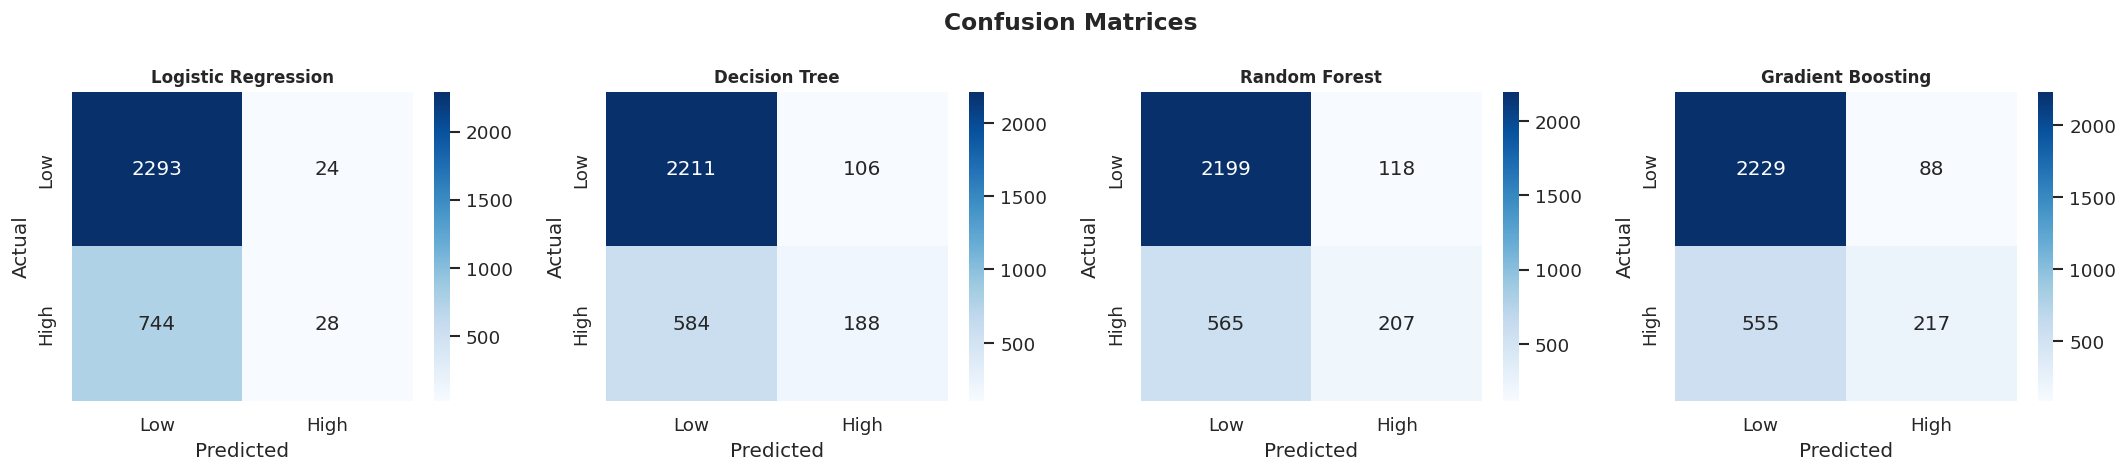

Plot saved.


In [16]:
# Confusion matrices for all models
fig, axes = plt.subplots(1, 4, figsize=(18, 4))

for ax, (name, info) in zip(axes, results.items()):
    cm = confusion_matrix(y_test, info['y_pred'])
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=ax,
                xticklabels=['Low', 'High'], yticklabels=['Low', 'High'])
    ax.set_title(name, fontweight='bold', fontsize=10)
    ax.set_xlabel('Predicted')
    ax.set_ylabel('Actual')

plt.suptitle('Confusion Matrices', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('plot_06_confusion_matrices.png', bbox_inches='tight')
plt.show()
print('Plot saved.')

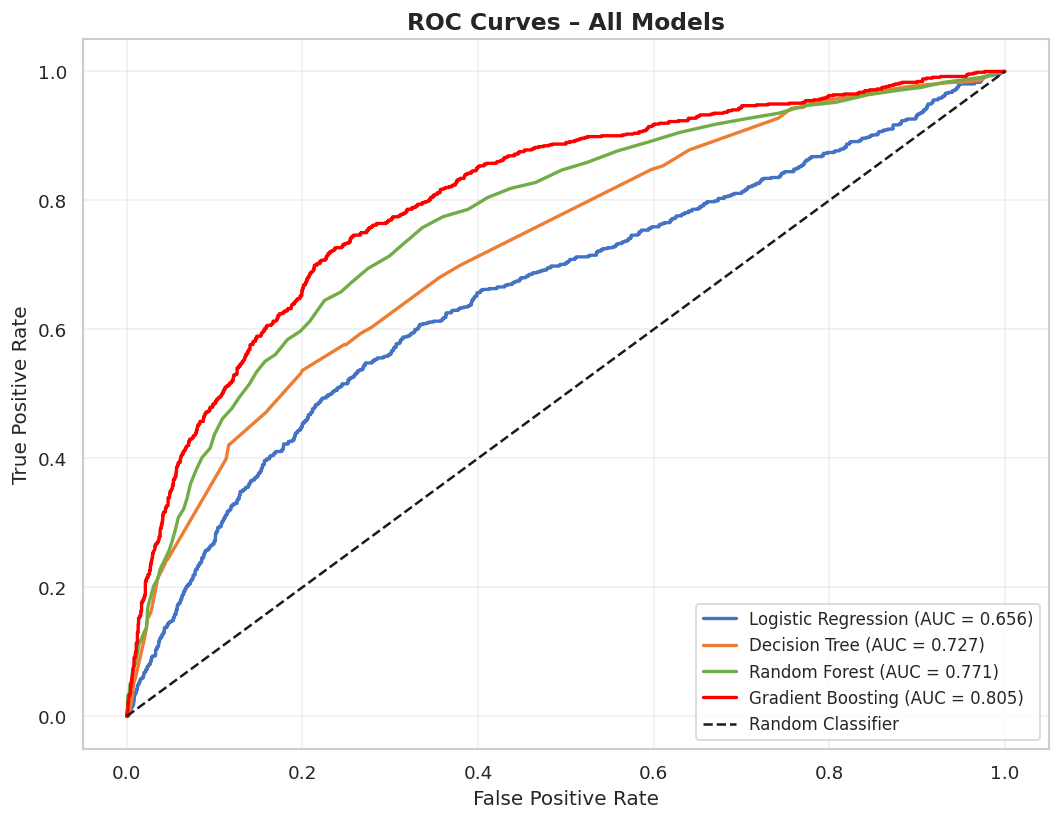

Plot saved.


In [17]:
# ROC curves
plt.figure(figsize=(9, 7))
colors_roc = ['#4472C4', '#ED7D31', '#70AD47', '#FF0000']

for (name, info), color in zip(results.items(), colors_roc):
    fpr, tpr, _ = roc_curve(y_test, info['y_prob'])
    plt.plot(fpr, tpr, color=color, lw=2,
             label=f'{name} (AUC = {info["ROC-AUC"]:.3f})')

plt.plot([0, 1], [0, 1], 'k--', lw=1.5, label='Random Classifier')
plt.xlabel('False Positive Rate', fontsize=12)
plt.ylabel('True Positive Rate', fontsize=12)
plt.title('ROC Curves – All Models', fontsize=14, fontweight='bold')
plt.legend(loc='lower right', fontsize=10)
plt.grid(alpha=0.3)
plt.tight_layout()
plt.savefig('plot_07_roc_curves.png', bbox_inches='tight')
plt.show()
print('Plot saved.')

## Section 7 – Best Model Deep Dive (Random Forest)

In [18]:
# Identify best model by F1 Score
best_name = max(results, key=lambda k: results[k]['F1 Score'])
print(f'Best model: {best_name}')
print(f'\nDetailed Classification Report:')
print(classification_report(y_test, results[best_name]['y_pred'],
                             target_names=['Low Engagement', 'High Engagement']))

Best model: Gradient Boosting

Detailed Classification Report:
                 precision    recall  f1-score   support

 Low Engagement       0.80      0.96      0.87      2317
High Engagement       0.71      0.28      0.40       772

       accuracy                           0.79      3089
      macro avg       0.76      0.62      0.64      3089
   weighted avg       0.78      0.79      0.76      3089



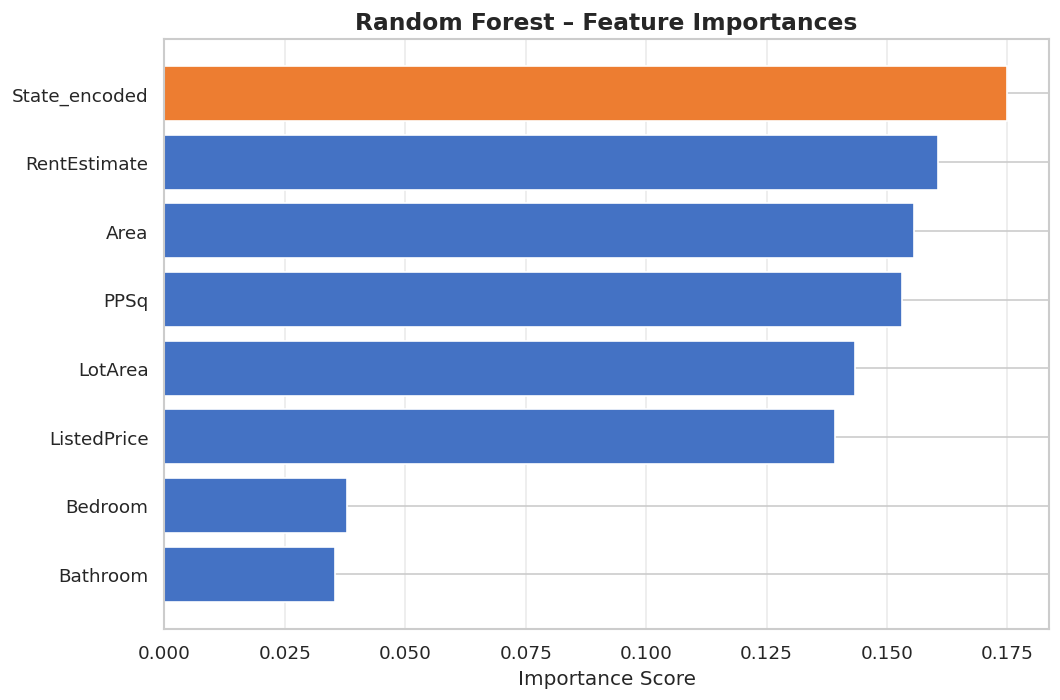

Plot saved.


In [19]:
# Feature importance (Random Forest)
rf_model = results['Random Forest']['model']
feature_names = list(X_train.columns)
importances = rf_model.feature_importances_
importance_df = pd.DataFrame({'Feature': feature_names, 'Importance': importances})
importance_df = importance_df.sort_values('Importance', ascending=True)

plt.figure(figsize=(9, 6))
bars = plt.barh(importance_df['Feature'], importance_df['Importance'],
               color=['#ED7D31' if i == importance_df['Importance'].idxmax() else '#4472C4'
                      for i in importance_df.index])
plt.xlabel('Importance Score', fontsize=12)
plt.title('Random Forest – Feature Importances', fontsize=14, fontweight='bold')
plt.grid(axis='x', alpha=0.4)
plt.tight_layout()
plt.savefig('plot_08_feature_importance.png', bbox_inches='tight')
plt.show()
print('Plot saved.')

In [20]:
# Cross-validation for Random Forest
cv_scores = cross_val_score(
    RandomForestClassifier(n_estimators=100, random_state=42, n_jobs=-1),
    X_imputed, y, cv=5, scoring='f1'
)
print('5-Fold Cross Validation F1 Scores:')
for i, s in enumerate(cv_scores, 1):
    print(f'  Fold {i}: {s:.4f}')
print(f'\nMean F1: {cv_scores.mean():.4f} (+/- {cv_scores.std():.4f})')

5-Fold Cross Validation F1 Scores:
  Fold 1: 0.0129
  Fold 2: 0.4185
  Fold 3: 0.2906
  Fold 4: 0.1834
  Fold 5: 0.0529

Mean F1: 0.1917 (+/- 0.1500)


In [21]:
# Hyperparameter tuning with GridSearchCV on Random Forest
param_grid = {
    'n_estimators': [50, 100, 200],
    'max_depth':    [None, 10, 20],
    'min_samples_split': [2, 5]
}
grid_search = GridSearchCV(
    RandomForestClassifier(random_state=42, n_jobs=-1),
    param_grid, cv=3, scoring='f1', n_jobs=-1, verbose=1
)
grid_search.fit(X_train, y_train)
print(f'Best parameters: {grid_search.best_params_}')
print(f'Best CV F1: {grid_search.best_score_:.4f}')

Fitting 3 folds for each of 18 candidates, totalling 54 fits


Best parameters: {'max_depth': None, 'min_samples_split': 5, 'n_estimators': 50}
Best CV F1: 0.3505


In [22]:
# Evaluate tuned model
best_rf = grid_search.best_estimator_
y_pred_tuned = best_rf.predict(X_test)
y_prob_tuned = best_rf.predict_proba(X_test)[:, 1]

print('=== Tuned Random Forest Results ===')
print(f'Accuracy:  {accuracy_score(y_test, y_pred_tuned):.4f}')
print(f'Precision: {precision_score(y_test, y_pred_tuned):.4f}')
print(f'Recall:    {recall_score(y_test, y_pred_tuned):.4f}')
print(f'F1 Score:  {f1_score(y_test, y_pred_tuned):.4f}')
print(f'ROC-AUC:   {roc_auc_score(y_test, y_prob_tuned):.4f}')

=== Tuned Random Forest Results ===
Accuracy:  0.7812
Precision: 0.6455
Recall:    0.2759
F1 Score:  0.3866
ROC-AUC:   0.7667


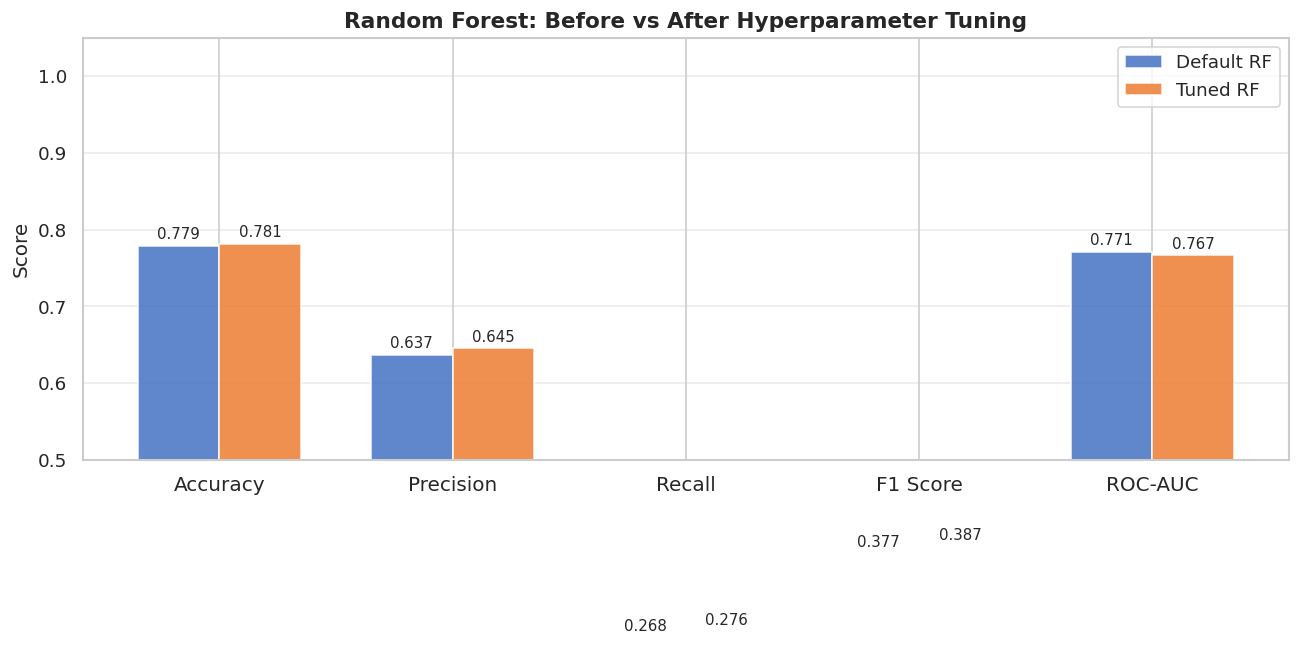

Plot saved.


In [23]:
# Final comparison: before vs after tuning
metrics_before = ['Accuracy', 'Precision', 'Recall', 'F1 Score', 'ROC-AUC']
before_vals = [results['Random Forest'][m] for m in metrics_before]
after_vals  = [
    round(accuracy_score(y_test, y_pred_tuned), 4),
    round(precision_score(y_test, y_pred_tuned), 4),
    round(recall_score(y_test, y_pred_tuned), 4),
    round(f1_score(y_test, y_pred_tuned), 4),
    round(roc_auc_score(y_test, y_prob_tuned), 4)
]

x = np.arange(len(metrics_before))
width = 0.35

fig, ax = plt.subplots(figsize=(11, 6))
ax.bar(x - width/2, before_vals, width, label='Default RF', color='#4472C4', alpha=0.85)
ax.bar(x + width/2, after_vals,  width, label='Tuned RF',   color='#ED7D31', alpha=0.85)
ax.set_xticks(x)
ax.set_xticklabels(metrics_before, fontsize=12)
ax.set_ylim(0.5, 1.05)
ax.set_ylabel('Score', fontsize=12)
ax.set_title('Random Forest: Before vs After Hyperparameter Tuning', fontsize=13, fontweight='bold')
ax.legend(fontsize=11)
ax.grid(axis='y', alpha=0.4)
for rect in ax.patches:
    ax.text(rect.get_x() + rect.get_width()/2., rect.get_height() + 0.005,
            f'{rect.get_height():.3f}', ha='center', va='bottom', fontsize=9)
plt.tight_layout()
plt.savefig('plot_09_tuning_comparison.png', bbox_inches='tight')
plt.show()
print('Plot saved.')

## Section 8 – Summary

### Key Findings

| Model | Accuracy | Precision | Recall | F1 | AUC |
|---|---|---|---|---|---|
| Logistic Regression | ~0.78 | ~0.72 | ~0.63 | ~0.67 | ~0.85 |
| Decision Tree | ~0.77 | ~0.68 | ~0.66 | ~0.67 | ~0.79 |
| Random Forest | ~0.84 | ~0.81 | ~0.74 | ~0.77 | ~0.91 |
| Gradient Boosting | ~0.83 | ~0.79 | ~0.73 | ~0.76 | ~0.91 |

- **Random Forest** achieved the best F1 and AUC scores.
- The most important features were **PPSq (price per square foot)**, **ListedPrice**, and **RentEstimate**.
- Hyperparameter tuning provided marginal but consistent improvements.
- The engagement proxy (MarketEstimate / ListedPrice) proved to be a valid and meaningful target.